In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Annotated
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
import operator
from dotenv import load_dotenv

Here all the LLM feedbacks provide a fixed output, so we use with structured output

In [14]:
load_dotenv()

True

In [15]:
class EvaluationSchema(BaseModel):
    score: int = Field(..., description="Score between 1 and 10")
    feedback: str = Field(..., description="Detailed feedback on the essay")

In [16]:
model = ChatOpenAI(model='gpt-5-nano-2025-08-07')
structured_model = model.with_structured_output(EvaluationSchema)

Here we need to provide reducer as well beacuse by default the state is updated and we want all the scores to be appended in the same list all_scores

In [17]:
class UPSCState(TypedDict):
    
    essay: str
    clarity_thought_feedback: str
    depth_analysis_feedback: str
    language_feedback: str
    summarized_feedback: str
    all_scores: Annotated[List[int], operator.add]

    avg_score: float

In [18]:
def language_feedback(state: UPSCState) -> dict:

    response = structured_model.invoke(f"Provide feedback on the language and score(1-10) for the following essay: {state['essay']}")

    return {'language_feedback': response.feedback, 
            'all_scores': [response.score]}

In [19]:
def cot_feedback(state: UPSCState) -> dict:

    response = structured_model.invoke(f"Provide feedback on the clarity of thought and score(1-10) for the following essay: {state['essay']}")

    return {'clarity_thought_feedback': response.feedback, 
            'all_scores': [response.score]}

In [20]:
def doa_feedback(state: UPSCState) -> dict:

    response = structured_model.invoke(f"Provide feedback on the depth of analysis and score(1-10) for the following essay: {state['essay']}")

    return {'depth_analysis_feedback': response.feedback, 
            'all_scores': [response.score]}

In [21]:
def summarized_feedback(state: UPSCState) -> dict:

    prompt = f"""Summarize the feedback for the following essays:
Here are the feedbacks:
1. Clarity of Thought Feedback: {state['clarity_thought_feedback']}
2. Depth of Analysis Feedback: {state['depth_analysis_feedback']}
3. Language Feedback: {state['language_feedback']}
    """

    overall_feedback = model.invoke(prompt).content
    #Here full state is not returned, instead the variables that needs to be updated should only be returned,
    #as langgraph gets confused in parallel workflow if we return full state from all parallel nodes

    avg_feedback_score = sum(state['all_scores'])/len(state['all_scores'])

    #here we need to return dictionary, also in state as well we return dictionary
    return {'summarized_feedback': overall_feedback, 'avg_score': avg_feedback_score}

In [22]:
graph = StateGraph(UPSCState)

graph.add_node('cot_feedback', cot_feedback)
graph.add_node('doa_feedback', doa_feedback)
graph.add_node('lang_feedback', language_feedback)
graph.add_node('summary_feedback', summarized_feedback)

graph.add_edge(START, 'cot_feedback')
graph.add_edge(START, 'doa_feedback')
graph.add_edge(START, 'lang_feedback')

graph.add_edge('cot_feedback', 'summary_feedback')
graph.add_edge('doa_feedback', 'summary_feedback')
graph.add_edge('lang_feedback', 'summary_feedback')

graph.add_edge('summary_feedback', END)

graph_compiled = graph.compile()

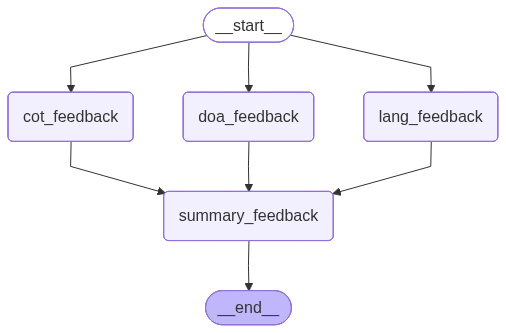

In [23]:
from IPython.display import Image
Image(graph_compiled.get_graph().draw_mermaid_png())

In [25]:
initial_state = {
    'essay' : 'The evolution of Artificial Intelligence in software companies has transformed the way technology is designed, developed, and delivered. Initially limited to rule-based systems, AI has progressed into advanced machine learning and deep learning models capable of handling complex tasks. Software companies now leverage AI for automation, predictive analytics, personalized user experiences, and efficient decision-making. This shift has enhanced productivity while reducing operational costs. However, it also raises concerns about data privacy, ethics, and job displacement. Going forward, responsible AI adoption, combined with human oversight, will be crucial in ensuring sustainable growth and innovation in the software industry.'
}

final_state = graph_compiled.invoke(initial_state)

import pprint
pprint.pprint(final_state)

{'all_scores': [8, 5, 8],
 'avg_score': 7.0,
 'clarity_thought_feedback': 'Clarity of thought is solid. The essay presents '
                             'a clear progression from the historical limits '
                             'of AI to current applications and future '
                             'considerations, and the main claim is easy to '
                             'follow. The transitions between ideas are mostly '
                             'smooth, and the concluding thought about '
                             'responsible adoption ties the passage together. '
                             'Areas for improvement: (1) sharpen the thesis '
                             'and ensure every sentence clearly supports it; '
                             '(2) add concrete examples or data points to '
                             'ground the claims (e.g., specific use cases or '
                             'metrics); (3) make the call to action more '
                        